In [3]:
from jsonl_from_tsv import convert_tsv_to_jsonl
import pandas as pd

In [2]:
import pandas as pd

# Assuming your file path is correct based on your previous code
df = pd.read_csv(
    "../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv",
    sep="\t",
)

print(f"Total length of DataFrame: {len(df)}")

# Get value counts, including NA/NaN values
constructive_class_counts = df["constructiveclass"].value_counts(dropna=False)
print("\nValue Counts (including NA):")
print(constructive_class_counts)

# Calculate the sum of these counts
sum_of_counts = constructive_class_counts.sum()
print(f"\nSum of value counts: {sum_of_counts}")

# You can also directly count the missing values
missing_values_count = df["constructiveclass"].isnull().sum()
print(f"Number of missing values (NaN/NA): {missing_values_count}")

# Verify the sum
print(f"Verification: {sum_of_counts} == {len(df)}")

Total length of DataFrame: 22536

Value Counts (including NA):
constructiveclass
Constructive        16010
Not constructive     5392
NaN                  1129
Something Else          5
Name: count, dtype: int64

Sum of value counts: 22536
Number of missing values (NaN/NA): 1129
Verification: 22536 == 22536


In [3]:
import pandas as pd
import numpy as np  # For np.nan

# Define your input path
input_path = "../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_turk_annotations.tsv"

try:
    # Read the TSV file, preventing pandas from interpreting 'NA' as NaN by default.
    # keep_default_na=False ensures that common strings like 'NA', '', '#N/A' etc.,
    # are NOT treated as NaN unless explicitly listed in na_values.
    # We also set na_values=[] to ensure no strings are converted to NaN.
    df_raw = pd.read_csv(
        input_path,
        sep="\t",
        keep_default_na=False,  # Important: Do not convert default missing value strings
        na_values=[],  # Important: Do not convert any specified values to NaN
    )

    print(f"Total length of DataFrame: {len(df_raw)}")

    # Get the 'constructiveclass' column
    constructive_class_series = df_raw["constructiveclass"]

    print("\n--- Value Counts with distinct NA/NaN ---")
    # Use value_counts(dropna=False) to count everything, including actual NaN/None
    # This will now differentiate between the string 'NA' and actual missing values
    # (represented as np.nan or None by pandas for truly empty cells after loading)
    all_distinct_counts = constructive_class_series.value_counts(dropna=False)
    print(all_distinct_counts)

    print("\n--- Further Breakdown ---")
    # Count how many are the string 'NA'
    count_string_na = (constructive_class_series == "NA").sum()
    print(f"Count of cells containing the string 'NA': {count_string_na}")

    # Count how many are actual pandas NaN values (from truly empty cells or other non-recognized missing markers)
    count_string_nan = (constructive_class_series == "NaN").sum()
    print(f"Count of cells containing the string 'NaN': {count_string_nan}")

    # Verify the sum
    total_sum_of_counts = all_distinct_counts.sum()
    print(f"\nSum of all distinct counts: {total_sum_of_counts}")
    print(
        f"Does sum of counts match DataFrame length? {total_sum_of_counts == len(df_raw)}"
    )

except FileNotFoundError:
    print(f"Error: The file '{input_path}' was not found. Please check the path.")
    # You might want to create a dummy DataFrame for testing here
    # For example:
    # data = {'constructiveclass': ['Constructive', 'Not constructive', 'NA', '', 'Constructive', 'NA', np.nan, 'Not constructive', None]}
    # df_raw = pd.DataFrame(data)
    # print("Using a dummy DataFrame for demonstration due to FileNotFoundError.")
    # Then re-run the counting logic on df_raw

Total length of DataFrame: 25532

--- Value Counts with distinct NA/NaN ---
constructiveclass
Constructive        12236
Not constructive    12191
NaN                  1105
Name: count, dtype: int64

--- Further Breakdown ---
Count of cells containing the string 'NA': 0
Count of cells containing the string 'NaN': 1105

Sum of all distinct counts: 25532
Does sum of counts match DataFrame length? True


In [4]:
# Preprocess the YNACC dataset expert annotations
input_data_path = [
    "../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv",
    "../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_turk_annotations.tsv",
]
output_data_path = "../data/ynacc_processed.jsonl"

convert_tsv_to_jsonl(input_data_path, output_data_path)

Reading ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv and normalizing 'NaN' and 'NA' to 'NA' string...
Processing line 0 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv...
Processing line 1000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv...
Processing line 2000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv...
Processing line 3000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv...
Processing line 4000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv...
Processing line 5000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv...
Processing line 6000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv...
Processing line 7000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv...
Processing line 8000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv...
Proce

Processing threads and writing JSONL: 100%|██████████| 2400/2400 [00:00<00:00, 44307.59it/s]


--- Majority Voting Summary ---
Total threads with 'NA' annotations (skipped): 338
Threads skipped (all annotations were 'NA'): 0
Threads skipped (tie in non-'NA' labels only): 180
Threads skipped (tie between 'NA' and a constructive label): 0
Threads resolved (NA was overall top, but non-NA label existed): 0
Threads resolved (clear non-'NA' majority): 1882
Total threads attempted to resolve: 2400
Max author number across all threads: 14
Processed data written to ../data/ynacc_processed.jsonl


In [5]:
input_data_path = [
    "../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv",
]
output_data_path = "../data/iac_processed.jsonl"

convert_tsv_to_jsonl(input_data_path, output_data_path)

Reading ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv and normalizing 'NaN' and 'NA' to 'NA' string...
Processing line 0 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv...
Processing line 1000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv...
Processing line 2000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv...
Processing line 3000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv...
Processing line 4000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv...
Processing line 5000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv...
Processing line 6000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv...
Processing line 7000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv...
Processing line 8000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv...
Processing line 9000 from ../datase

Processing threads and writing JSONL: 100%|██████████| 986/986 [00:00<00:00, 39501.63it/s]


--- Majority Voting Summary ---
Total threads with 'NA' annotations (skipped): 217
Threads skipped (all annotations were 'NA'): 0
Threads skipped (tie in non-'NA' labels only): 0
Threads skipped (tie between 'NA' and a constructive label): 0
Threads resolved (NA was overall top, but non-NA label existed): 0
Threads resolved (clear non-'NA' majority): 769
Total threads attempted to resolve: 986
Max author number across all threads: 18
Processed data written to ../data/iac_processed.jsonl


In [ ]:
import json
import pandas as pd
from transformers import BertTokenizerFast
import numpy as np
import matplotlib.pyplot as plt
import os


def analyze_token_distribution(jsonl_file_path, model_name="bert-base-uncased"):
    """
    Reads a JSONL file, tokenizes the 'text' field using a BERT tokenizer,
    and analyzes the distribution of token counts.

    Args:
        jsonl_file_path (str): Path to the input JSONL file.
        model_name (str): The name of the pre-trained BERT model to use for tokenization.
    """
    print(f"Loading data from {jsonl_file_path}...")
    data = []
    try:
        with open(jsonl_file_path, "r", encoding="utf-8") as f:
            for line in f:
                data.append(json.loads(line))
    except FileNotFoundError:
        print(
            f"Error: JSONL data file not found at {jsonl_file_path}. Please check the path."
        )
        return

    if not data:
        print("No data loaded. Exiting analysis.")
        return

    df = pd.DataFrame(data)
    print(f"Successfully loaded {len(df)} entries.")

    print(f"Initializing tokenizer for '{model_name}'...")
    tokenizer = BertTokenizerFast.from_pretrained(model_name)

    token_counts = []
    print("Tokenizing texts and counting tokens (this might take a moment)...")
    for index, row in df.iterrows():
        # Tokenize without truncation to get the actual full length
        encoding = tokenizer.encode_plus(
            str(row["text"]),
            add_special_tokens=True,
            return_token_type_ids=False,
            return_attention_mask=False,
            truncation=False,  # IMPORTANT: Do not truncate here, we want actual length
        )
        token_counts.append(len(encoding["input_ids"]))

    token_counts_np = np.array(token_counts)

    print("\n--- Token Count Distribution ---")
    print(f"Total threads: {len(token_counts_np)}")
    print(f"Minimum tokens: {np.min(token_counts_np)}")
    print(f"Maximum tokens: {np.max(token_counts_np)}")
    print(f"Mean tokens: {np.mean(token_counts_np):.2f}")
    print(f"Median tokens: {np.median(token_counts_np)}")
    print(f"Standard deviation: {np.std(token_counts_np):.2f}")

    print("\n--- Percentiles ---")
    percentiles = [50, 75, 90, 95, 99, 100]  # Include 100th for max
    for p in percentiles:
        val = np.percentile(token_counts_np, p)
        print(f"{p}th percentile: {int(val)} tokens")

    # Calculate proportion of threads above 512 tokens
    above_512 = np.sum(token_counts_np > 512)
    proportion_above_512 = (above_512 / len(token_counts_np)) * 100
    print(
        f"\nThreads with more than 512 tokens: {above_512} ({proportion_above_512:.2f}%)"
    )

    # Optional: Plotting a histogram
    print("\nAttempting to plot histogram (requires matplotlib)...")
    try:
        plt.figure(figsize=(12, 6))
        plt.hist(token_counts_np, bins=50, color="skyblue", edgecolor="black")
        plt.title("Distribution of Token Counts per Thread")
        plt.xlabel(f"Number of Tokens ({model_name} Tokenizer)")
        plt.ylabel("Number of Threads")
        plt.axvline(x=512, color="red", linestyle="--", label="BERT Max Length (512)")
        plt.legend()
        plt.grid(axis="y", alpha=0.75)
        plt.show()
        print("Histogram displayed successfully.")
    except Exception as e:
        print(f"Could not plot histogram. Error: {e}")
        print("Please ensure 'matplotlib' is installed (`pip install matplotlib`)")

Loading data from ../data/ynacc_processed.jsonl...
Successfully loaded 1882 entries.
Initializing tokenizer for 'bert-base-uncased'...


Token indices sequence length is longer than the specified maximum sequence length for this model (767 > 512). Running this sequence through the model will result in indexing errors


Tokenizing texts and counting tokens (this might take a moment)...

--- Token Count Distribution ---
Total threads: 1882
Minimum tokens: 28
Maximum tokens: 4401
Mean tokens: 421.49
Median tokens: 330.0
Standard deviation: 337.02

--- Percentiles ---
50th percentile: 330 tokens
75th percentile: 550 tokens
90th percentile: 802 tokens
95th percentile: 985 tokens
99th percentile: 1623 tokens
100th percentile: 4401 tokens

Threads with more than 512 tokens: 526 (27.95%)

Attempting to plot histogram (requires matplotlib)...


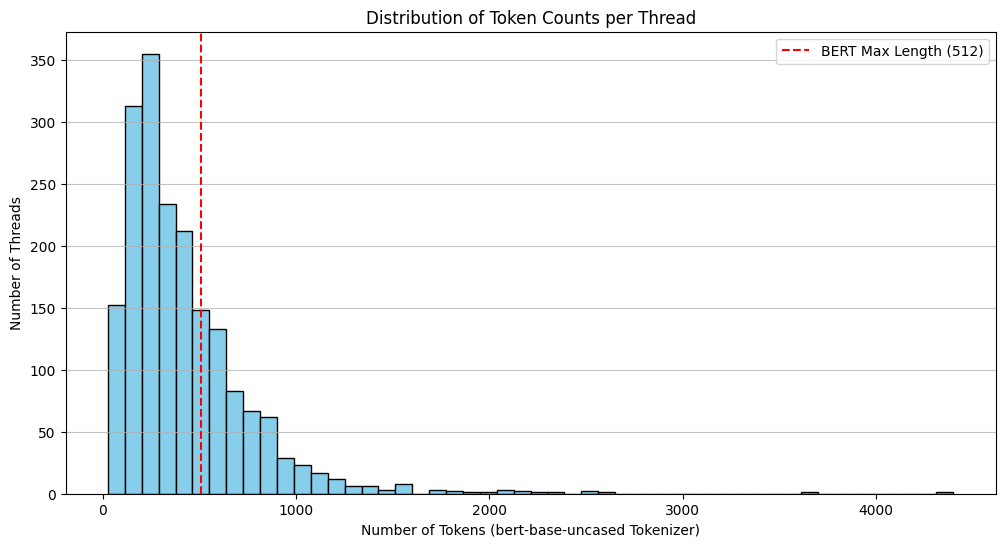

Histogram displayed successfully.


In [4]:
jsonl_file_path = "../data/ynacc_processed.jsonl"
analyze_token_distribution(jsonl_file_path)

Loading data from ../data/iac_processed.jsonl...
Successfully loaded 769 entries.
Initializing tokenizer for 'bert-base-uncased'...


Token indices sequence length is longer than the specified maximum sequence length for this model (535 > 512). Running this sequence through the model will result in indexing errors


Tokenizing texts and counting tokens (this might take a moment)...

--- Token Count Distribution ---
Total threads: 769
Minimum tokens: 69
Maximum tokens: 7963
Mean tokens: 1119.97
Median tokens: 784.0
Standard deviation: 1048.76

--- Percentiles ---
50th percentile: 784 tokens
75th percentile: 1421 tokens
90th percentile: 2309 tokens
95th percentile: 3159 tokens
99th percentile: 5172 tokens
100th percentile: 7963 tokens

Threads with more than 512 tokens: 536 (69.70%)

Attempting to plot histogram (requires matplotlib)...


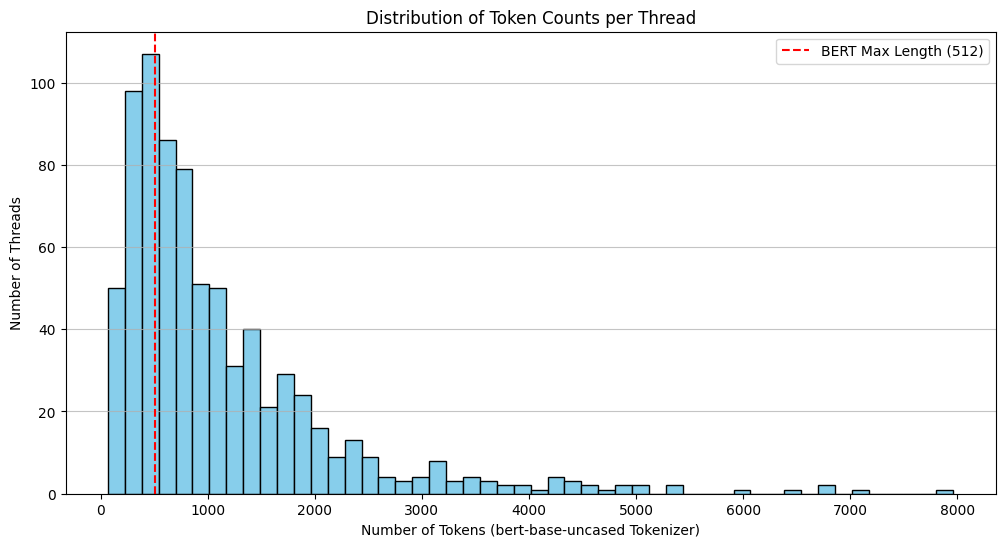

Histogram displayed successfully.


In [3]:
jsonl_file_path = "../data/iac_processed.jsonl"
analyze_token_distribution(jsonl_file_path)

In [6]:
ynacc = pd.read_json("../data/ynacc_processed.jsonl", lines=True, encoding="utf-8")
iac = pd.read_json("../data/iac_processed.jsonl", lines=True, encoding="utf-8")
print(
    f"YNACC dataset balance: {ynacc['label'].value_counts()}, {ynacc['label'].value_counts(normalize=True)}"
)
print(
    f"IAC dataset balance: {iac['label'].value_counts()}, {iac['label'].value_counts(normalize=True)}"
)

YNACC dataset balance: label
1    963
0    919
Name: count, dtype: int64, label
1    0.51169
0    0.48831
Name: proportion, dtype: float64
IAC dataset balance: label
1    613
0    156
Name: count, dtype: int64, label
1    0.797139
0    0.202861
Name: proportion, dtype: float64


In [1]:
import json


def remove_label_key(input_file, output_file):
    """
    Removes the 'label' key and its value from each JSON object in a .jsonl file.

    Args:
        input_file (str): Path to the input .jsonl file.
        output_file (str): Path to the output .jsonl file where modified objects will be written.
    """
    with open(input_file, "r", encoding="utf-8") as infile, open(
        output_file, "w", encoding="utf-8"
    ) as outfile:
        for line in infile:
            try:
                data = json.loads(line)
                if "label" in data:
                    del data["label"]
                outfile.write(json.dumps(data) + "\n")
            except json.JSONDecodeError as e:
                print(f"Skipping malformed JSON line: {line.strip()} - Error: {e}")


remove_label_key("../data/reddit_train_labeled.jsonl", "../data/reddit_train.jsonl")